## Initialization

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from MSTOkG.MSTOOpt import *
from joblib import Parallel, delayed
import sys
import time 
from IPython.display import clear_output, display
from tqdm import tqdm
import pandas as pd

## H

In [4]:
compute=False
if compute:
    dirname = 'testdata'
    elements = ['H', 'H']
    bondlengths = np.linspace(0.5, 1.2, 100)
    
    for basis, prefix in [("6-31g", "BS")]+[(f"sto-{k}g", "BS") for k in range(2,7)]+[(f"msto-{k:02d}g", "MOBS") for k in range(2,12)]:
    
        
        # prefix = "BS"
        basisset = {}
        for element in elements:
            basisset.update(loadBSI(os.path.join(dirname, f"{prefix}_{element}_{basis}.pickle"))['mol_CISD'].mol.basis)
        
        mol = pyscf.M(
                    atom = f"{elements[0]} 0.0 0.0 0.0; {elements[1]} 0.0 0.0 2;", # in Angstrom
                    basis = basisset,
                    symmetry = False,
                    spin=0
                )
        
        enlst={'HF': [],
            'FCI': [],
            'CISD': []}
        
        for bl in tqdm(bondlengths):
            mol.atom = f"{elements[0]} 0.0 0.0 0.0; {elements[1]} 0.0 0.0 {bl};" # in Angstrom
            mol.build()
            en = getEnergies(mol, nroots=4, fci=True, cisd=True)
            en['FCI'] = en['FCI'][0]
            for approx in ['HF', 'FCI', 'CISD']:
                enlst[approx].append(en[approx])
        
        
        enlst.update({"R": bondlengths})
        df = pd.DataFrame(enlst)[["R", "HF", "FCI", "CISD"]]
        df.to_csv(f"EvsR_{''.join(elements)}_{basis}.csv", index=False)
        print(f"Basis: {basis}; Complete")

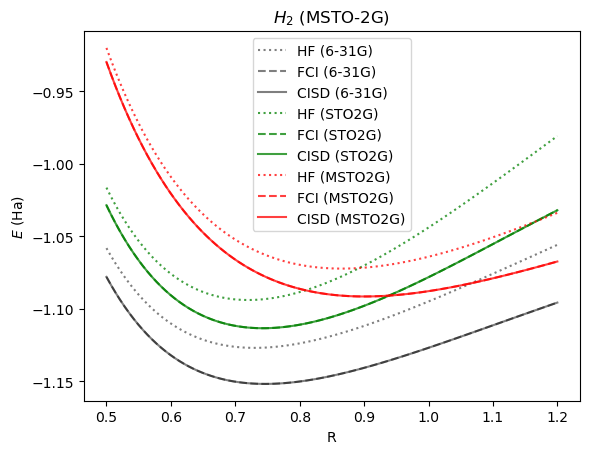

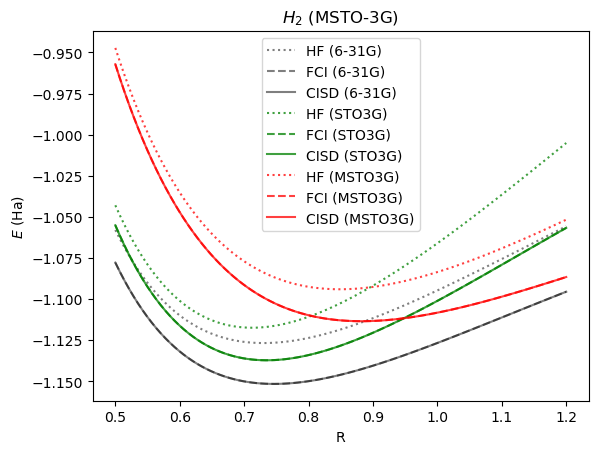

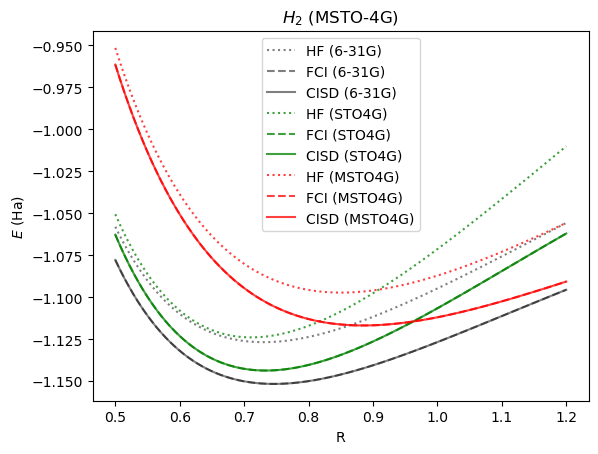

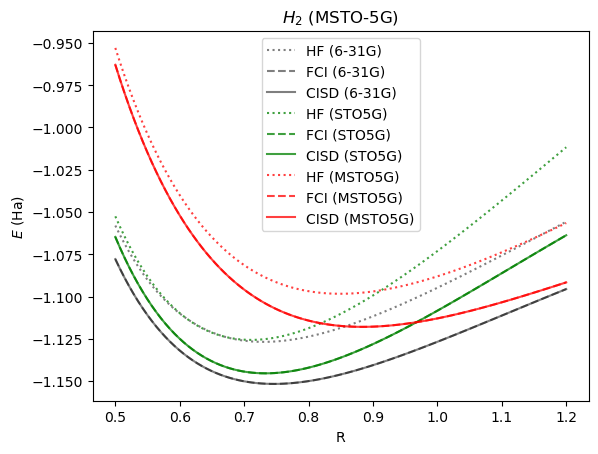

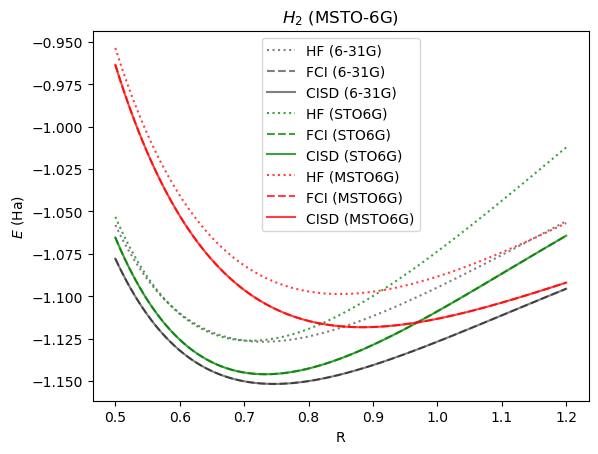

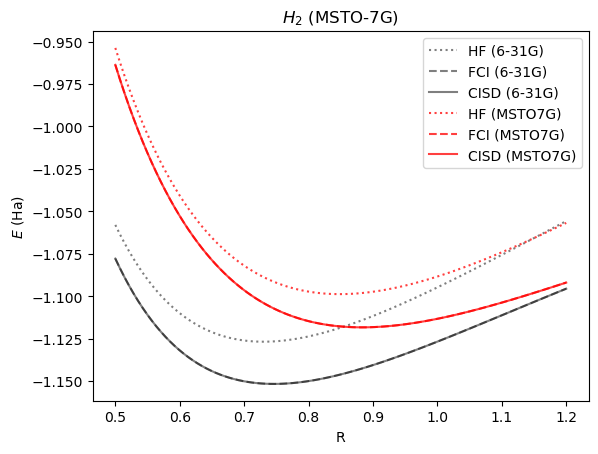

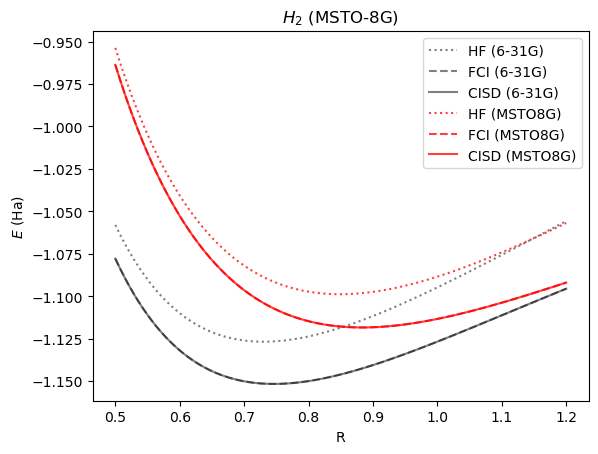

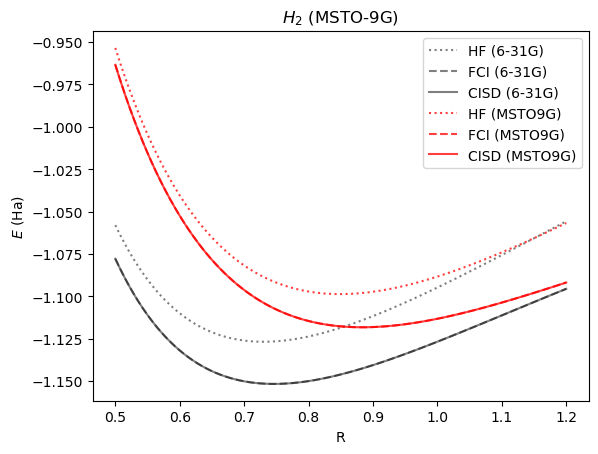

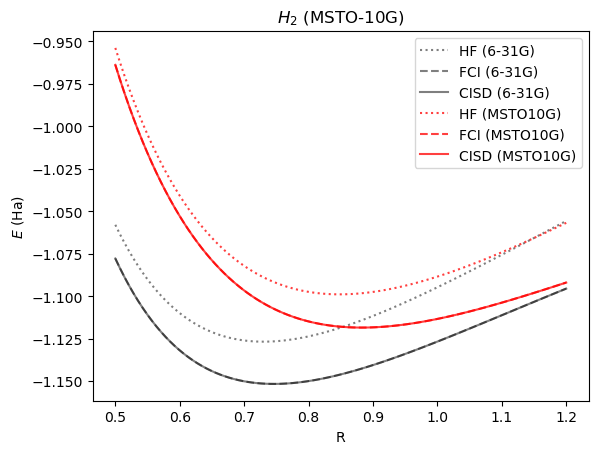

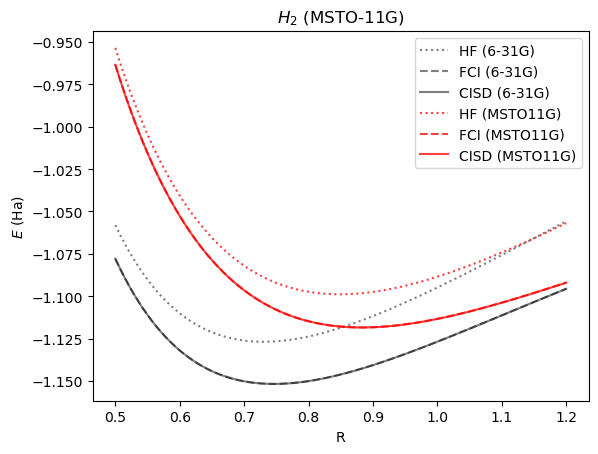

In [5]:
molname = 'HH'

for k in range(2,12):
    fig = pl.figure()
    ax = fig.add_subplot(1,1,1)
    
    df631g = pd.read_csv(f"EvsR_{molname}_6-31g.csv")
    df631g = df631g.rename(columns={'HF':'HF (6-31G)', 'FCI':'FCI (6-31G)', 'CISD':'CISD (6-31G)'})
    df631g.plot(x='R', y=['HF (6-31G)', 'FCI (6-31G)', 'CISD (6-31G)'], ax=ax, style=['k:', 'k--', 'k-'], alpha=0.5)

    try:
        dstokg = pd.read_csv(f"EvsR_{molname}_sto-{k}g.csv")
        dstokg = dstokg.rename(columns={'HF':f'HF (STO{k}G)', 'FCI':f'FCI (STO{k}G)', 'CISD':f'CISD (STO{k}G)'})
        dstokg.plot(x='R', y=[f'HF (STO{k}G)', f'FCI (STO{k}G)', f'CISD (STO{k}G)'], ax=ax, style=['g:', 'g--', 'g-'], alpha=0.75)
    except:
        pass
    
    dmstokg = pd.read_csv(f"EvsR_{molname}_msto-{k:02d}g.csv")
    dmstokg = dmstokg.rename(columns={'HF':f'HF (MSTO{k}G)', 'FCI':f'FCI (MSTO{k}G)', 'CISD':f'CISD (MSTO{k}G)'})
    dmstokg.plot(x='R', y=[f'HF (MSTO{k}G)', f'FCI (MSTO{k}G)', f'CISD (MSTO{k}G)'], ax=ax, style=['r:', 'r--', 'r-'], alpha=0.75)
    ax.set_ylabel(r"$E$ (Ha)")
    ax.set_title(r"$H_2$"+ f" (MSTO-{k}G)")
    pl.savefig(f"EvsR-H2(MSTO-{k}G).png")

In [3]:
compute = False
# compute = True
if compute:
    dirname = 'testdata'
    elements = ['Li', 'H']
    bondlengths = np.linspace(1, 3, 100)
    
    for basis, prefix in [("6-31g", "BS")]+[(f"sto-{k}g", "BS") for k in range(2,7)]+[(f"msto-{k:02d}g", "MOBS") for k in range(2,12)]:
    
        
        # prefix = "BS"
        basisset = {}
        for element in elements:
            basisset.update(loadBSI(os.path.join(dirname, f"{prefix}_{element}_{basis}.pickle"))['mol_CISD'].mol.basis)
        
        mol = pyscf.M(
                    atom = f"{elements[0]} 0.0 0.0 0.0; {elements[1]} 0.0 0.0 2;", # in Angstrom
                    basis = basisset,
                    symmetry = False,
                    spin=0
                )
        
        enlst={'HF': [],
            'FCI': [],
            'CISD': [],
              'DM_'+basis:[]}
        
        for bl in tqdm(bondlengths):
            mol.atom = f"{elements[0]} 0.0 0.0 0.0; {elements[1]} 0.0 0.0 {bl};" # in Angstrom
            mol.build()
            en = getEnergies(mol, nroots=4, fci=True, cisd=True)
            en['FCI'] = en['FCI'][0]
            for approx in ['HF', 'FCI', 'CISD']:
                enlst[approx].append(en[approx])
            mf = scf.RHF(mol) # RHF for closed shell UHF for open-shell systems
            mf.verbose=0
            mf.kernel()
            dipole_moment_vector = mf.dip_moment(verbose=0)
            total_dipole_moment_magnitude = np.linalg.norm(dipole_moment_vector)
            enlst['DM_'+basis].append(total_dipole_moment_magnitude)
        
        enlst.update({"R": bondlengths})
        df = pd.DataFrame(enlst)[["R", "HF", "FCI", "CISD", 'DM_'+basis]]
        df.to_csv(f"EvsR_{''.join(elements)}_{basis}.csv", index=False)
        print(f"Basis: {basis}; Complete")

## LiH

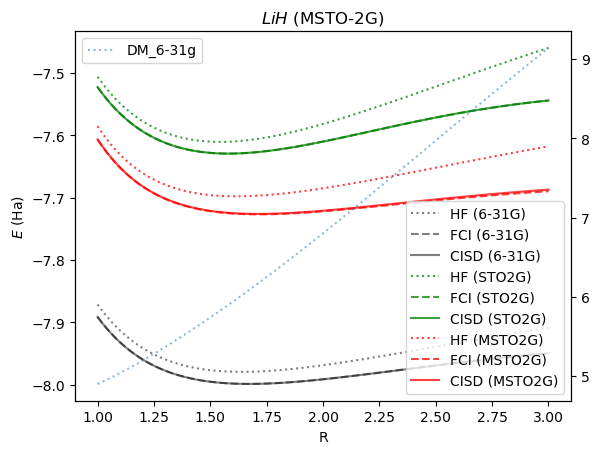

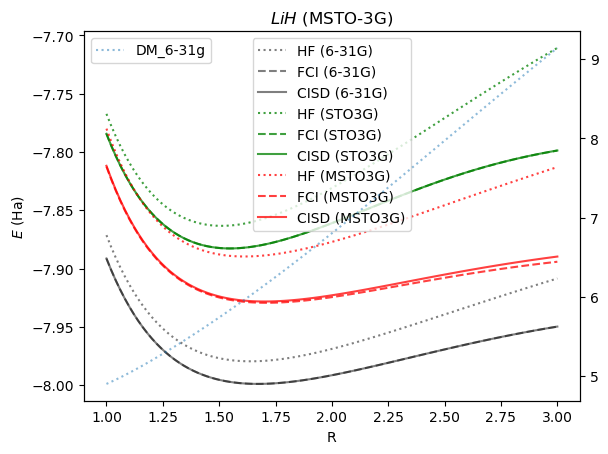

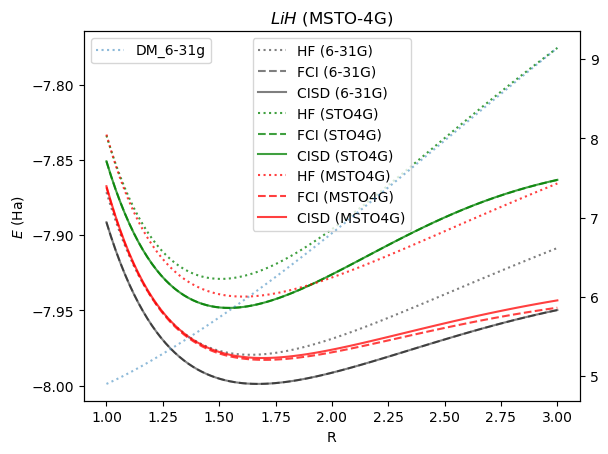

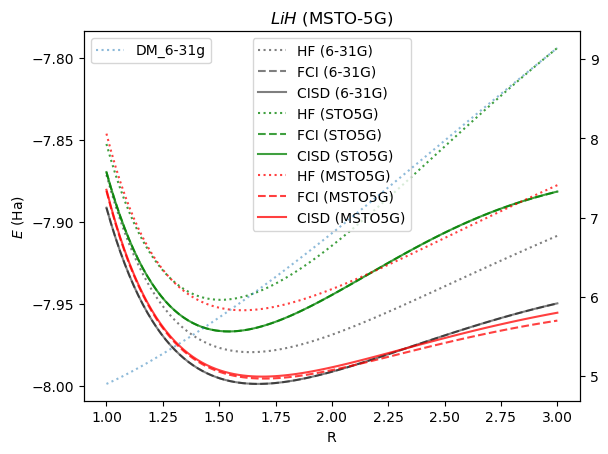

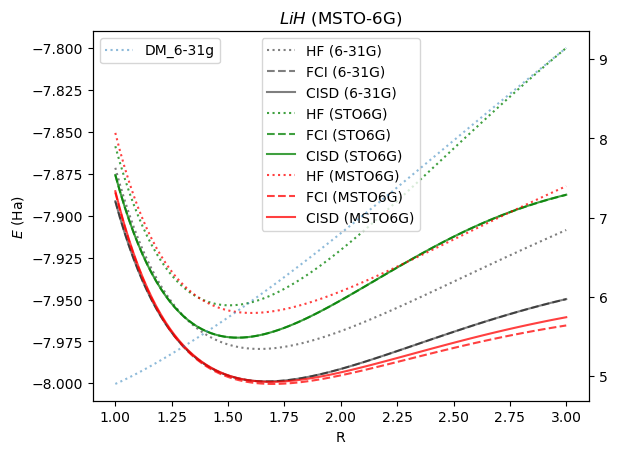

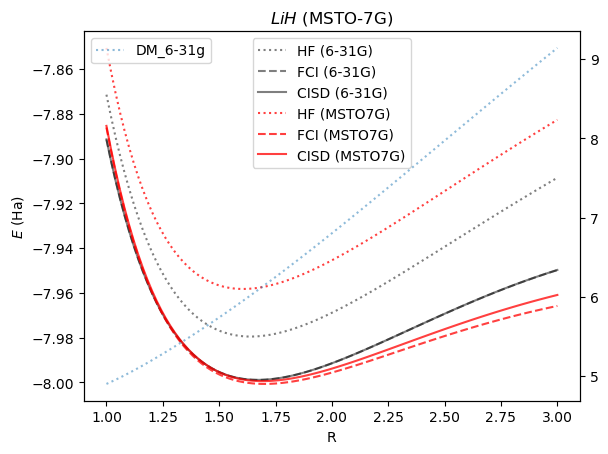

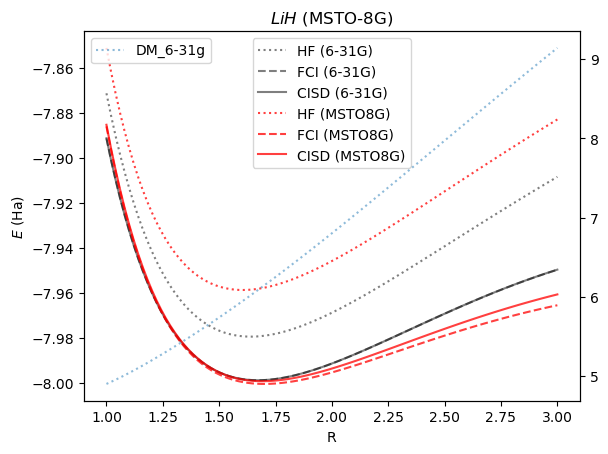

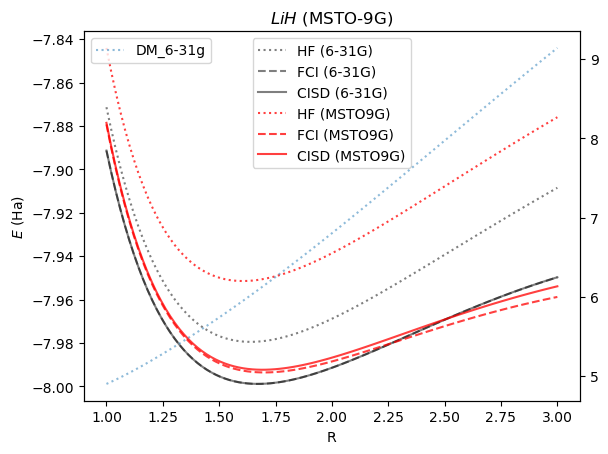

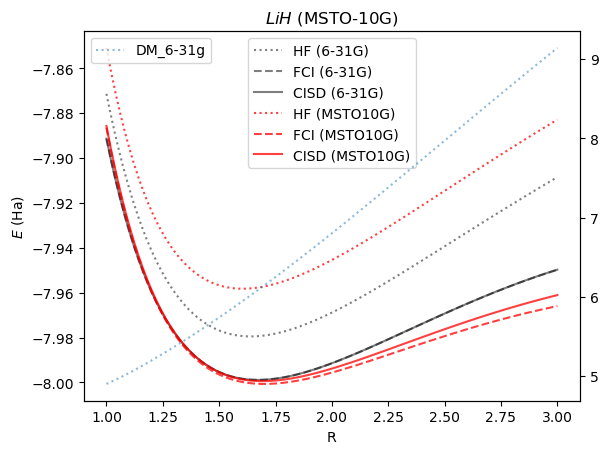

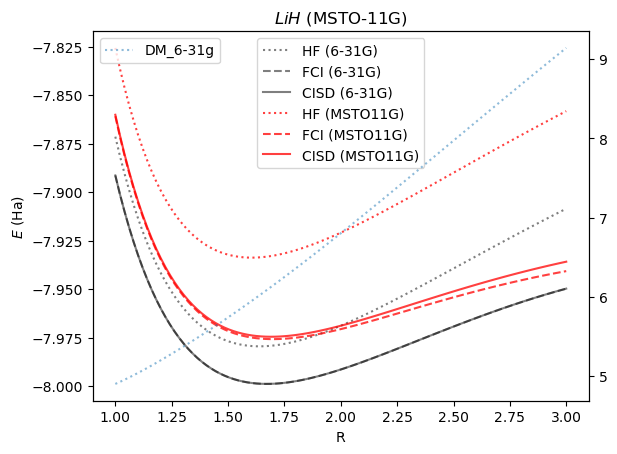

In [4]:
molname = 'LiH'

for k in range(2,12):
    fig = pl.figure()
    ax = fig.add_subplot(1,1,1)
    ax_dp = ax.twinx()
    
    df631g = pd.read_csv(f"EvsR_{molname}_6-31g.csv")
    df631g = df631g.rename(columns={'HF':'HF (6-31G)', 'FCI':'FCI (6-31G)', 'CISD':'CISD (6-31G)'})
    df631g.plot(x='R', y=['HF (6-31G)', 'FCI (6-31G)', 'CISD (6-31G)'], ax=ax, style=['k:', 'k--', 'k-'], alpha=0.5)
    df631g.plot(x='R', y=['DM_6-31g'], ax=ax_dp, style=[':'], alpha=0.5)

    try:
        dstokg = pd.read_csv(f"EvsR_{molname}_sto-{k}g.csv")
        dstokg = dstokg.rename(columns={'HF':f'HF (STO{k}G)', 'FCI':f'FCI (STO{k}G)', 'CISD':f'CISD (STO{k}G)'})
        dstokg.plot(x='R', y=[f'HF (STO{k}G)', f'FCI (STO{k}G)', f'CISD (STO{k}G)'], ax=ax, style=['g:', 'g--', 'g-'], alpha=0.75)
    except:
        pass
    
    dmstokg = pd.read_csv(f"EvsR_{molname}_msto-{k:02d}g.csv")
    dmstokg = dmstokg.rename(columns={'HF':f'HF (MSTO{k}G)', 'FCI':f'FCI (MSTO{k}G)', 'CISD':f'CISD (MSTO{k}G)'})
    dmstokg.plot(x='R', y=[f'HF (MSTO{k}G)', f'FCI (MSTO{k}G)', f'CISD (MSTO{k}G)'], ax=ax, style=['r:', 'r--', 'r-'], alpha=0.75)
    ax.set_ylabel(r"$E$ (Ha)")
    ax.set_title(r"$LiH$"+ f" (MSTO-{k}G)")
    pl.savefig(f"EvsR-LiH(MSTO-{k}G).png")

In [11]:
df631g

,R,HF (6-31G),FCI (6-31G),CISD (6-31G),DM_6-31g
0,1.000000,-7.871356,-7.891374,-7.891351,4.900038
1,1.020202,-7.881177,-7.900944,-7.900923,4.925713
2,1.040404,-7.890263,-7.909798,-7.909778,4.952628
3,1.060606,-7.898662,-7.917986,-7.917967,4.980648
4,1.080808,-7.906421,-7.925554,-7.925536,5.009656
...,...,...,...,...,...
95,2.919192,-7.913308,-7.952453,-7.952405,8.957366
96,2.939394,-7.912097,-7.951766,-7.951717,9.003946
97,2.959596,-7.910892,-7.951092,-7.951042,9.050406
98,2.979798,-7.909692,-7.950432,-7.950381,9.096739


## $O_2$

The computation demands 46 GB of RAM. Hence this will have to be done on a suitaable system (perhaps the IITKGP cluster).

In [8]:
compute=False
if compute:
    dirname = 'testdata'
    elements = ['H', 'F']
    bondlengths = np.linspace(1, 3, 10)
    
    for basis, prefix in [("6-31g", "BS")]:#+[(f"sto-{k}g", "BS") for k in range(2,7)]+[(f"msto-{k:02d}g", "MOBS") for k in range(2,12)]:
    # for basis, prefix in [(f"sto-{k}g", "BS") for k in range(2,7)]+[(f"msto-{k:02d}g", "MOBS") for k in range(2,12)]:
    
        
        # prefix = "BS"
        basisset = {}
        for element in elements:
            basisset.update(loadBSI(os.path.join(dirname, f"{prefix}_{element}_{basis}.pickle"))['mol_CISD'].mol.basis)
        
        mol = pyscf.M(
                    atom = f"{elements[0]} 0.0 0.0 0.0; {elements[1]} 0.0 0.0 0.92;", # in Angstrom
                    basis = basisset,
                    symmetry = False,
                    spin=2,
                    charge=0
                )
        
        enlst={'HF': [],
            'FCI': [],
            'CISD': []}
        
        for bl in tqdm(bondlengths):
            mol.atom = f"{elements[0]} 0.0 0.0 0.0; {elements[1]} 0.0 0.0 {bl};" # in Angstrom
            mol.build()
            en = getEnergies(mol, nroots=4, fci=True, cisd=True)
            en['FCI'] = en['FCI'][0]
            for approx in ['HF', 'FCI', 'CISD']:
                enlst[approx].append(en[approx])
        
        
        enlst.update({"R": bondlengths})
        df = pd.DataFrame(enlst)[["R", "HF", "FCI", "CISD"]]
        df.to_csv(f"EvsR_{''.join(elements)}_{basis}.csv", index=False)
        print(f"Basis: {basis}; Complete")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [14:20<00:00, 86.01s/it]

Basis: 6-31g; Complete


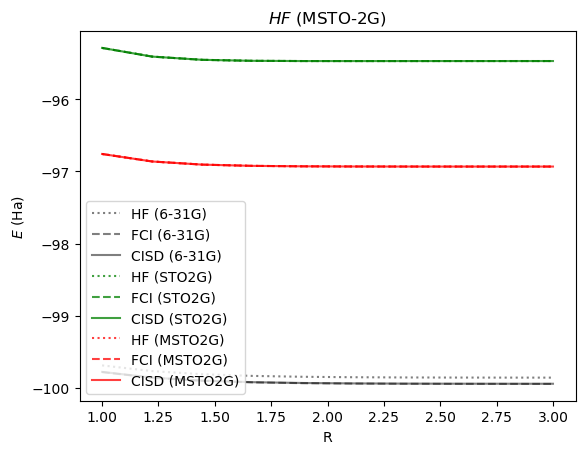

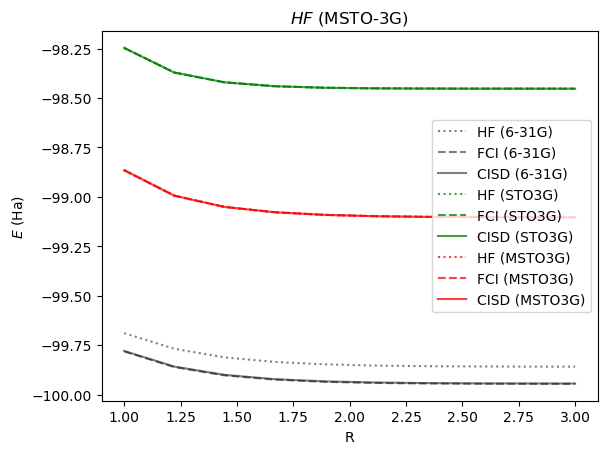

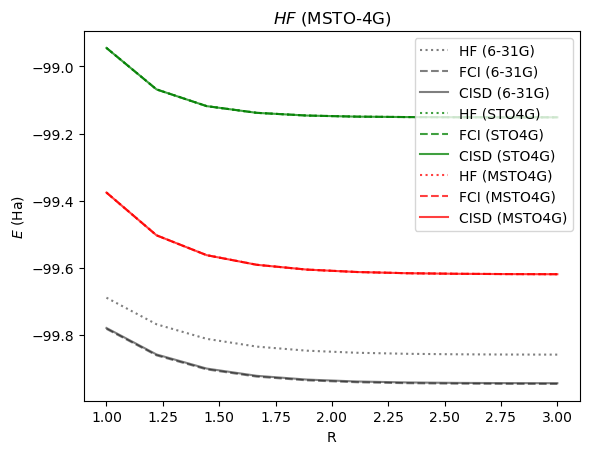

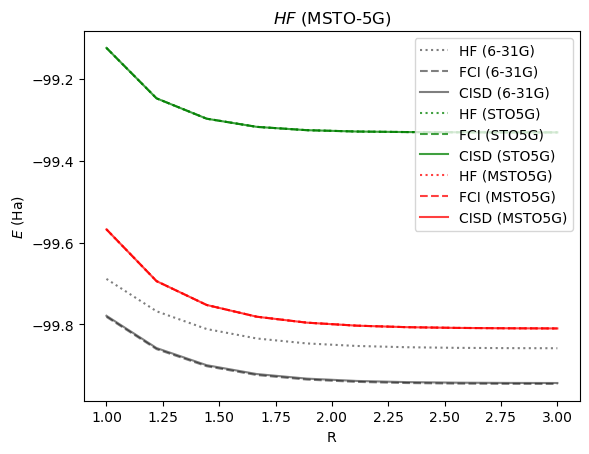

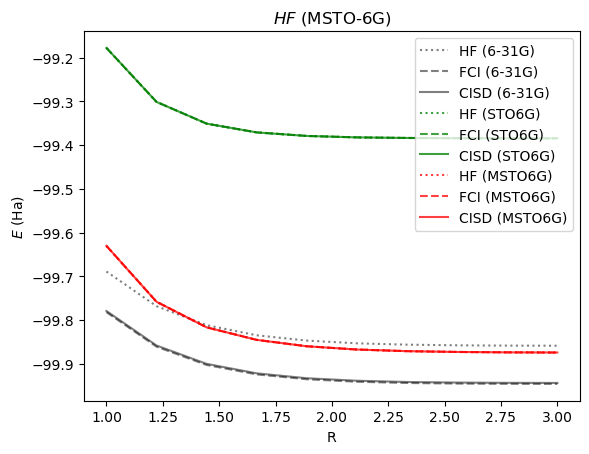

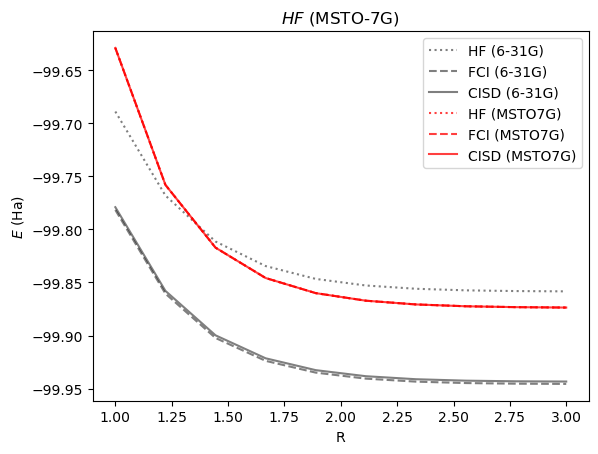

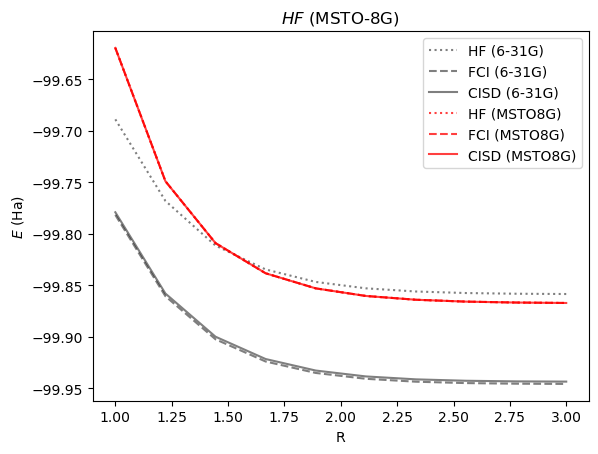

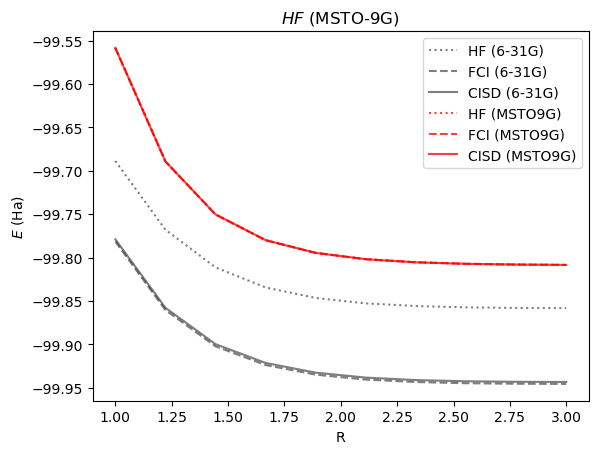

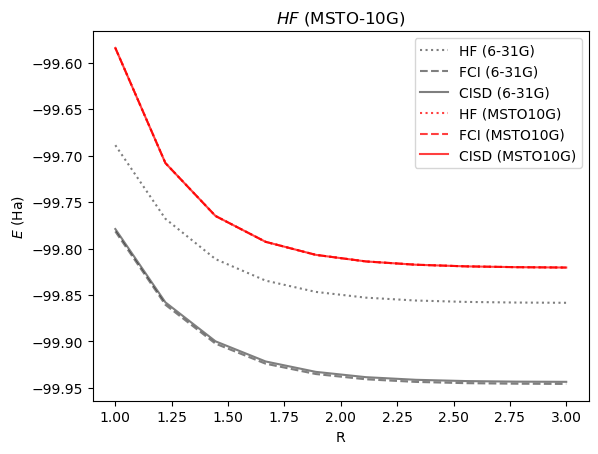

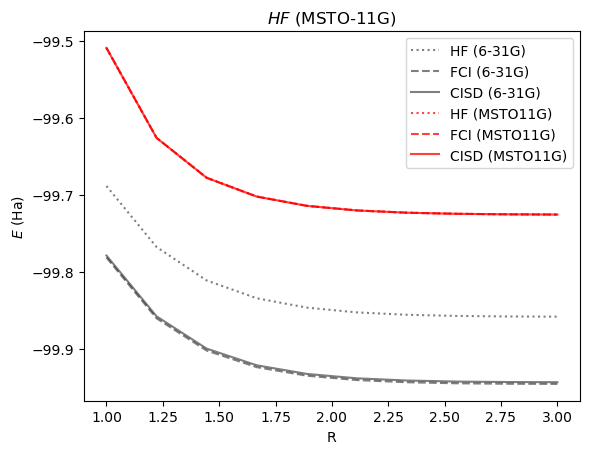

In [9]:
molname = 'HF'

for k in range(2,12):
    fig = pl.figure()
    ax = fig.add_subplot(1,1,1)
    
    df631g = pd.read_csv(f"EvsR_{molname}_6-31g.csv")
    df631g = df631g.rename(columns={'HF':'HF (6-31G)', 'FCI':'FCI (6-31G)', 'CISD':'CISD (6-31G)'})
    df631g.plot(x='R', y=['HF (6-31G)', 'FCI (6-31G)', 'CISD (6-31G)'], ax=ax, style=['k:', 'k--', 'k-'], alpha=0.5)

    try:
        dstokg = pd.read_csv(f"EvsR_{molname}_sto-{k}g.csv")
        dstokg = dstokg.rename(columns={'HF':f'HF (STO{k}G)', 'FCI':f'FCI (STO{k}G)', 'CISD':f'CISD (STO{k}G)'})
        dstokg.plot(x='R', y=[f'HF (STO{k}G)', f'FCI (STO{k}G)', f'CISD (STO{k}G)'], ax=ax, style=['g:', 'g--', 'g-'], alpha=0.75)
    except:
        pass
    
    dmstokg = pd.read_csv(f"EvsR_{molname}_msto-{k:02d}g.csv")
    dmstokg = dmstokg.rename(columns={'HF':f'HF (MSTO{k}G)', 'FCI':f'FCI (MSTO{k}G)', 'CISD':f'CISD (MSTO{k}G)'})
    dmstokg.plot(x='R', y=[f'HF (MSTO{k}G)', f'FCI (MSTO{k}G)', f'CISD (MSTO{k}G)'], ax=ax, style=['r:', 'r--', 'r-'], alpha=0.75)
    ax.set_ylabel(r"$E$ (Ha)")
    ax.set_title(r"$HF$"+ f" (MSTO-{k}G)")
    pl.savefig(f"EvsR-HF(MSTO-{k}G).png")

In [ ]:
compute=True
if compute:
    dirname = 'testdata'
    elements = ['O', 'O']
    bondlengths = np.linspace(1, 2, 10)
    
    # for basis, prefix in [("6-31g", "BS")]:#+[(f"sto-{k}g", "BS") for k in range(2,7)]+[(f"msto-{k:02d}g", "MOBS") for k in range(2,12)]:
    for basis, prefix in [(f"sto-{k}g", "BS") for k in range(2,7)]+[(f"msto-{k:02d}g", "MOBS") for k in range(2,12)]:
    
        
        # prefix = "BS"
        basisset = {}
        for element in elements:
            basisset.update(loadBSI(os.path.join(dirname, f"{prefix}_{element}_{basis}.pickle"))['mol_CISD'].mol.basis)
        
        mol = pyscf.M(
                    atom = f"{elements[0]} 0.0 0.0 0.0; {elements[1]} 0.0 0.0 1.2;", # in Angstrom
                    basis = basisset,
                    symmetry = False,
                    spin=2,
                    charge=0
                )
        
        enlst={'HF': [],
            'FCI': [],
            'CISD': []}
        
        for bl in tqdm(bondlengths):
            mol.atom = f"{elements[0]} 0.0 0.0 0.0; {elements[1]} 0.0 0.0 {bl};" # in Angstrom
            mol.build()
            en = getEnergies(mol, nroots=4, fci=True, cisd=True)
            en['FCI'] = en['FCI'][0]
            for approx in ['HF', 'FCI', 'CISD']:
                enlst[approx].append(en[approx])
        
        
        enlst.update({"R": bondlengths})
        df = pd.DataFrame(enlst)[["R", "HF", "FCI", "CISD"]]
        df.to_csv(f"EvsR_{''.join(elements)}_{basis}.csv", index=False)
        print(f"Basis: {basis}; Complete")

 70%|████████████████████████████████████████████████████████████████████████████████████                                    | 7/10 [01:03<00:33, 11.31s/it]

In [ ]:
molname = 'OO'

for k in range(2,12):
    fig = pl.figure()
    ax = fig.add_subplot(1,1,1)
    
    # df631g = pd.read_csv(f"EvsR_{molname}_6-31g.csv")
    # df631g = df631g.rename(columns={'HF':'HF (6-31G)', 'FCI':'FCI (6-31G)', 'CISD':'CISD (6-31G)'})
    # df631g.plot(x='R', y=['HF (6-31G)', 'FCI (6-31G)', 'CISD (6-31G)'], ax=ax, style=['k:', 'k--', 'k-'], alpha=0.5)

    try:
        dstokg = pd.read_csv(f"EvsR_{molname}_sto-{k}g.csv")
        dstokg = dstokg.rename(columns={'HF':f'HF (STO{k}G)', 'FCI':f'FCI (STO{k}G)', 'CISD':f'CISD (STO{k}G)'})
        dstokg.plot(x='R', y=[f'HF (STO{k}G)', f'FCI (STO{k}G)', f'CISD (STO{k}G)'], ax=ax, style=['g:', 'g--', 'g-'], alpha=0.75)
    except:
        pass
    
    dmstokg = pd.read_csv(f"EvsR_{molname}_msto-{k:02d}g.csv")
    dmstokg = dmstokg.rename(columns={'HF':f'HF (MSTO{k}G)', 'FCI':f'FCI (MSTO{k}G)', 'CISD':f'CISD (MSTO{k}G)'})
    dmstokg.plot(x='R', y=[f'HF (MSTO{k}G)', f'FCI (MSTO{k}G)', f'CISD (MSTO{k}G)'], ax=ax, style=['r:', 'r--', 'r-'], alpha=0.75)
    ax.set_ylabel(r"$E$ (Ha)")
    ax.set_title(r"$O_2$"+ f" (MSTO-{k}G)")
    pl.savefig(f"EvsR-O2(MSTO-{k}G).png")